## 1. 数据加载与预处理
包含：读入数据、类型转换、缺失值处理、衍生特征（ret_close、range_pct、oc_pct）等。

In [1]:
# P1.0 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei']  # 兼容中文（如本机无该字体，可删掉这行）
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

# P1.1 读入数据
path = './沪深300_最近三年.csv'
df_raw = pd.read_csv(path)
df_raw.head()

,日期,收盘,开盘,高,低,交易量,涨跌幅
0,2026-03-13,4698.64,4669.06,4707.42,4669.06,123533.67K,0.24%
1,2026-03-12,4687.56,4700.72,4704.38,4654.31,302986.82K,-0.36%
2,2026-03-11,4704.50,4681.03,4711.87,4674.71,270175.44K,0.64%
3,2026-03-10,4674.76,4648.79,4677.60,4648.79,263903.75K,1.28%
4,2026-03-09,4615.46,4600.25,4625.98,4548.97,322787.62K,-0.97%


In [2]:
# P1.2 数据清洗：类型转换、缺失处理、排序

df = df_raw.copy()

# 日期
df['日期'] = pd.to_datetime(df['日期'], errors='coerce')

# 交易量：形如 123533.67K -> 数值（单位：K）与原始“股/手”未知，这里统一转为“千”为单位的数值
# 同时保留一个更直观的数值列 volume_k
vol = df['交易量'].astype(str).str.replace(',', '', regex=False)
vol = vol.str.replace('K', '', regex=False)
df['volume_k'] = pd.to_numeric(vol, errors='coerce')

# 涨跌幅：形如 0.24% -> 数值（%）与小数收益率
chg = df['涨跌幅'].astype(str).str.replace('%', '', regex=False)
df['pct_change'] = pd.to_numeric(chg, errors='coerce')          # 百分比数值

df = df.drop(columns=['涨跌幅', '交易量'])

# OHLC 转数值
for c in ['收盘', '开盘', '高', '低']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 按日期升序并去除日期缺失
n0 = len(df)
df = df.dropna(subset=['日期']).sort_values('日期').reset_index(drop=True)

# 补充：用收盘价计算收益率（小数形式），用于后续分析；并与 pct_change 对比
# ret_close = (Close_t / Close_{t-1} - 1)
df['ret_close'] = df['收盘'].pct_change()

# 价格波动特征
# 当日振幅（相对开盘/收盘都可，这里用收盘归一）
df['range_pct'] = (df['高'] - df['低']) / df['收盘']
# 当日实体（开收差）
df['oc_pct'] = (df['收盘'] - df['开盘']) / df['开盘']

# 缺失概览
print('清洗前行数:', n0)
print('清洗后行数:', len(df))
print('\n缺失值计数：')
print(df.isna().sum())

df.head()

清洗前行数: 727
清洗后行数: 727

缺失值计数：
日期            0
收盘            0
开盘            0
高             0
低             0
volume_k      0
pct_change    1
ret_close     1
range_pct     0
oc_pct        0
dtype: int64


,日期,收盘,开盘,高,低,volume_k,pct_change,ret_close,range_pct,oc_pct
0,2023-03-13,4008.69,3962.64,4008.69,3962.64,143561.37,NaN,NaN,0.011488,0.011621
1,2023-03-14,3984.70,3999.88,4001.94,3946.94,150544.17,-0.60,-0.005984,0.013803,-0.003795
2,2023-03-15,3986.90,4011.84,4018.75,3986.90,142026.01,0.06,0.000552,0.007989,-0.006217
3,2023-03-16,3939.15,3958.20,3981.32,3936.48,152515.64,-1.20,-0.011977,0.011383,-0.004813
4,2023-03-17,3958.82,3971.16,4004.22,3945.25,177433.82,0.50,0.004993,0.014896,-0.003107


In [3]:
# 缺失数据统计（参考上机示例：按列统计缺失数量与占比）
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum() / df.shape[0]).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
print('缺失数据统计（仅显示有缺失的列）：')
print(missing_data[missing_data['Total'] > 0])
if missing_data['Total'].eq(0).all():
    print('各列均无缺失。')

缺失数据统计（仅显示有缺失的列）：
            Total   Percent
pct_change      1  0.001376
ret_close       1  0.001376


## 2. 描述性统计分析
对数值列做 describe()，并计算偏度、峰度等，用于判断分布形态与正态性。

In [5]:
# P1.3 描述性统计

# 基本信息
print(df.dtypes)
print('\n时间范围:', df['日期'].min().date(), '->', df['日期'].max().date())
print('样本量:', len(df))

# 收盘价统计特征
print('\n收盘价 describe:')
print(df['收盘'].describe())

# 收益率统计特征（剔除首日 NaN）
ret = df['ret_close'].dropna()
print('\n日收益率（ret_close）describe:')
print(ret.describe())

print('\n收益率偏度/峰度:')
print('偏度:', float(ret.skew()))
print('峰度:', float(ret.kurt()))

日期            datetime64[ns]
收盘                   float64
开盘                   float64
高                    float64
低                    float64
volume_k             float64
pct_change           float64
ret_close            float64
range_pct            float64
oc_pct               float64
dtype: object

时间范围: 2023-03-13 -> 2026-03-13
样本量: 727

收盘价 describe:
count     727.000000
mean     3894.650591
std       413.818990
min      3159.250000
25%      3572.435000
50%      3865.470000
75%      4036.510000
max      4790.690000
Name: 收盘, dtype: float64

日收益率（ret_close）describe:
count    726.000000
mean       0.000276
std        0.010711
min       -0.070515
25%       -0.005349
50%       -0.000118
75%        0.005183
max        0.084826
Name: ret_close, dtype: float64

收益率偏度/峰度:
偏度: 0.45780254730302433
峰度: 12.073570769348663


In [6]:
# 正态性检验（参考上机：对日收益率等做正态性检验）
# Shapiro-Wilk（小样本）或 D'Agostino K² 正态性检验
ret = df['ret_close'].dropna()
# Shapiro-Wilk 适用于较小样本（一般 n<=5000）
if len(ret) <= 5000:
    stat_sw, p_sw = stats.shapiro(ret)
    print('Shapiro-Wilk 正态性检验（日收益率 ret_close）：')
    print(f'  统计量 = {stat_sw:.6f}, p-value = {p_sw:.6f}')
    print('  p < 0.05 时拒绝正态性假设。')
else:
    stat_sw, p_sw = stats.shapiro(ret.sample(5000, random_state=42))
    print('Shapiro-Wilk 正态性检验（日收益率 ret_close，抽样 n=5000）：')
    print(f'  统计量 = {stat_sw:.6f}, p-value = {p_sw:.6f}')
stat_dag, p_dag = stats.normaltest(ret)
print('D\'Agostino K² 正态性检验（日收益率 ret_close）：')
print(f'  统计量 = {stat_dag:.6f}, p-value = {p_dag:.6f}')
print('  p < 0.05 时拒绝正态性假设。')

Shapiro-Wilk 正态性检验（日收益率 ret_close）：
  统计量 = 0.887017, p-value = 0.000000
  p < 0.05 时拒绝正态性假设。
D'Agostino K² 正态性检验（日收益率 ret_close）：
  统计量 = 176.616846, p-value = 0.000000
  p < 0.05 时拒绝正态性假设。


## 3. 数据可视化分析
包括：价格走势图、收益率分布与 QQ 图、箱线图（离群值检测）、正态性/对数转换对比等。

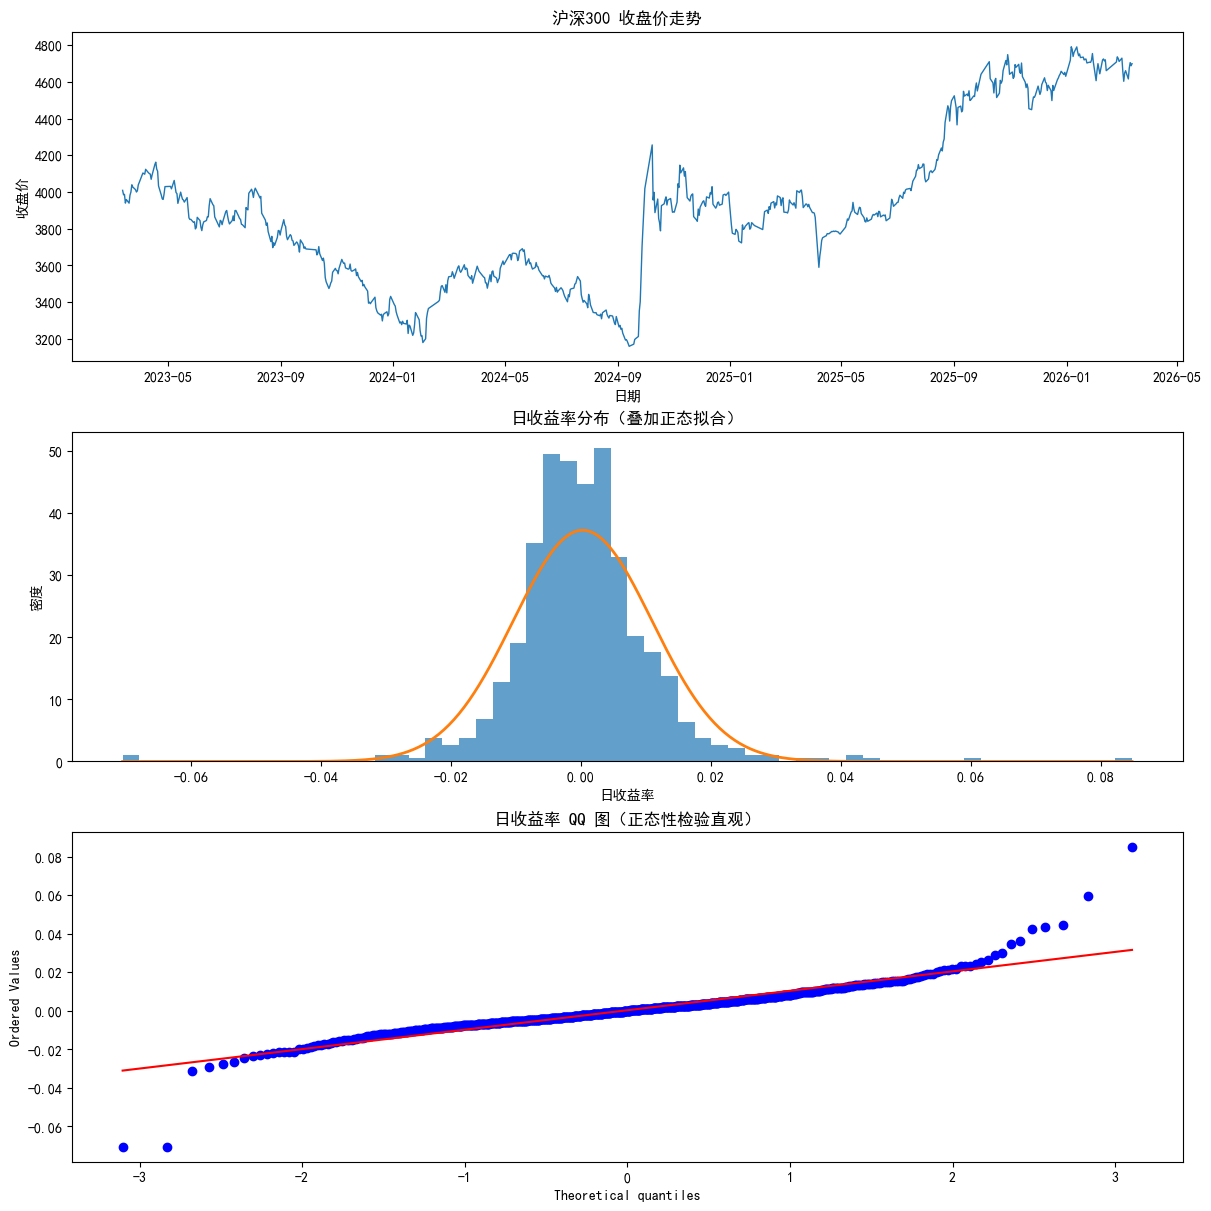

In [8]:
# P1.4 可视化：价格走势、收益率分布、QQ图

fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

axes[0].plot(df['日期'], df['收盘'], linewidth=1)
axes[0].set_title('沪深300 收盘价走势')
axes[0].set_xlabel('日期')
axes[0].set_ylabel('收盘价')

axes[1].hist(ret, bins=60, density=True, alpha=0.7)
mu, sigma = ret.mean(), ret.std()
x = np.linspace(ret.min(), ret.max(), 400)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2)
axes[1].set_title('日收益率分布（叠加正态拟合）')
axes[1].set_xlabel('日收益率')
axes[1].set_ylabel('密度')

stats.probplot(ret, dist='norm', plot=axes[2])
axes[2].set_title('日收益率 QQ 图（正态性检验直观）')

plt.show()

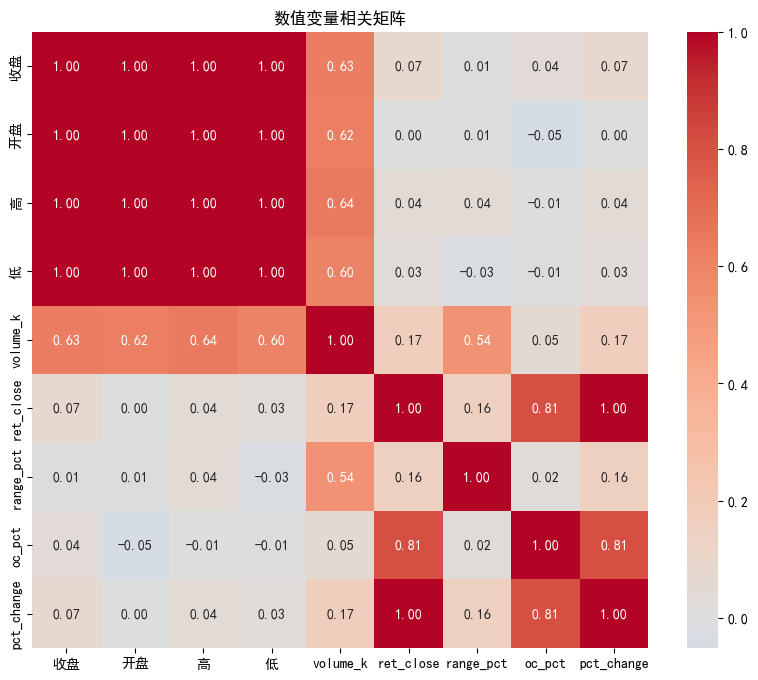

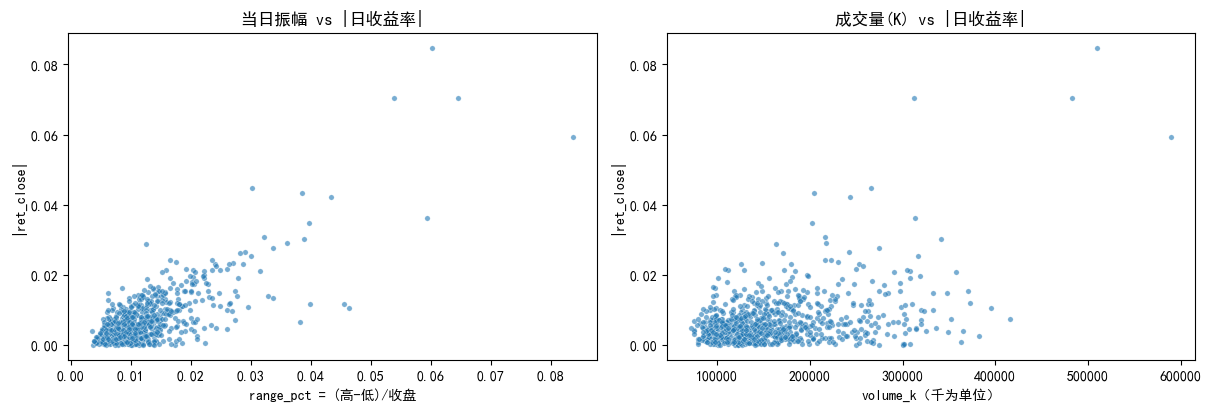

In [9]:
# P1.5 变量关系分析：相关矩阵、散点

num_cols = ['收盘', '开盘', '高', '低', 'volume_k', 'ret_close', 'range_pct', 'oc_pct', 'pct_change']

corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('数值变量相关矩阵')
plt.show()

# 两个典型关系：当日振幅 vs |收益率|；成交量 vs |收益率|
plot_df = df.dropna(subset=['ret_close', 'range_pct', 'volume_k']).copy()
plot_df['abs_ret'] = plot_df['ret_close'].abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.scatterplot(data=plot_df, x='range_pct', y='abs_ret', s=15, alpha=0.6, ax=axes[0])
axes[0].set_title('当日振幅 vs |日收益率|')
axes[0].set_xlabel('range_pct = (高-低)/收盘')
axes[0].set_ylabel('|ret_close|')

sns.scatterplot(data=plot_df, x='volume_k', y='abs_ret', s=15, alpha=0.6, ax=axes[1])
axes[1].set_title('成交量(K) vs |日收益率|')
axes[1].set_xlabel('volume_k（千为单位）')
axes[1].set_ylabel('|ret_close|')

plt.show()

## 4. 相关性分析
相关系数矩阵、热力图，以及典型变量间的散点图（如振幅 vs 绝对收益率、成交量 vs 绝对收益率）。

In [11]:
# P1.6 简单建模：用当日特征预测“下一交易日收益率”
# 参考示例中的回归系数与残差图思路

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_df = df[['日期', 'ret_close', 'range_pct', 'oc_pct', 'volume_k']].copy()

# 目标：下一日收益率
model_df['y_next_ret'] = model_df['ret_close'].shift(-1)

# 清理缺失（首日 ret_close NaN；最后一日 y_next_ret NaN）
model_df = model_df.dropna().reset_index(drop=True)

X = model_df[['ret_close', 'range_pct', 'oc_pct', 'volume_k']]
y = model_df['y_next_ret']

# 时间序列划分：前 80% 训练、后 20% 测试
split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

lr = LinearRegression()
lr.fit(X_train, y_train)

yhat_train = lr.predict(X_train)
yhat_test = lr.predict(X_test)

def report(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} - MSE: {mse:.8f}, MAE: {mae:.6f}, R2: {r2:.4f}")

print('回归系数（特征 -> 预测下一日收益率）')
coef = pd.Series(lr.coef_, index=X.columns)
print(coef.sort_values(key=lambda s: s.abs(), ascending=False))
print('截距:', float(lr.intercept_))

print('\n模型评估：')
report(y_train, yhat_train, 'Train')
report(y_test, yhat_test, 'Test')

回归系数（特征 -> 预测下一日收益率）
oc_pct       2.380341e-01
range_pct    1.063299e-01
ret_close   -9.701444e-02
volume_k     2.305240e-09
dtype: float64
截距: -0.0016326885832552728

模型评估：
Train - MSE: 0.00011823, MAE: 0.007246, R2: 0.0259
Test - MSE: 0.00009220, MAE: 0.007582, R2: -0.0586


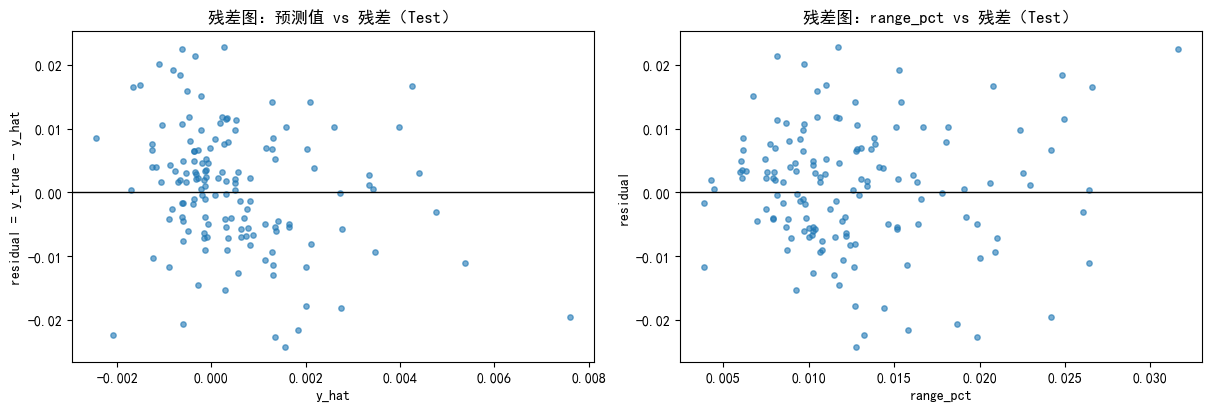

In [12]:
# P1.7 残差图（参考示例）

# 残差 = 真实 - 预测
resid_test = y_test - yhat_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# 1) 预测值 vs 残差
axes[0].scatter(yhat_test, resid_test, s=15, alpha=0.6)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('残差图：预测值 vs 残差（Test）')
axes[0].set_xlabel('y_hat')
axes[0].set_ylabel('residual = y_true - y_hat')

# 2) 其中一个特征（振幅）vs 残差
axes[1].scatter(X_test['range_pct'], resid_test, s=15, alpha=0.6)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('残差图：range_pct vs 残差（Test）')
axes[1].set_xlabel('range_pct')
axes[1].set_ylabel('residual')

plt.show()

## 5. 简单线性回归分析
多元线性回归（当日特征预测下一日收益率）、残差图、一元回归手工计算系数与 R²、MSE 等。

### 同方差与异方差（残差图与检验）

经典线性回归的重要假设之一是 **同方差（homoscedasticity）**：残差的方差应不随预测值或自变量变化而改变。

- **同方差**：残差在 0 线两侧均匀分布，波动范围大致稳定，残差图呈“带状”。
- **异方差（heteroscedasticity）**：残差方差随预测值或某一自变量增大而增大（或减小），残差图呈“喇叭口”“漏斗形”等。金融数据中常见“波动大时残差也大”。

若存在异方差，OLS 估计仍无偏，但标准误不可靠，推断（t 检验、置信区间）可能失效；可考虑 **稳健标准误（如 White、HC）** 或 **加权最小二乘（WLS）**。

下面先绘制残差图进行直观判断，再进行异方差检验。

相关系数 r: 0.7617732494990096
beta_1: 0.7875951836628048
beta_0: -0.0025372770973015654
MSE: 2.5949767037360875e-05


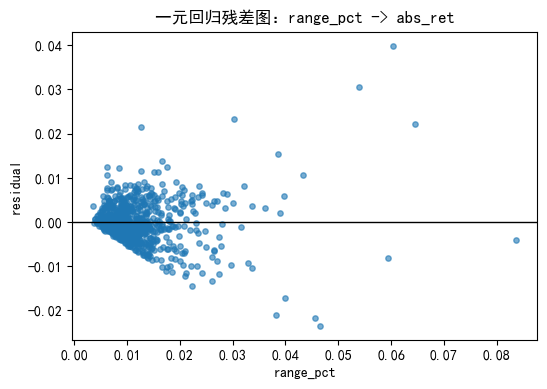

In [15]:
# P1.8 手工计算一元回归系数（beta0/beta1）示例
# 用当日振幅 range_pct 去解释“绝对收益率 abs_ret”（仅作方法演示）

sample = df[['range_pct', 'ret_close']].dropna().copy()
sample['abs_ret'] = sample['ret_close'].abs()

x = sample['range_pct']
y2 = sample['abs_ret']

x_avg, y_avg = x.mean(), y2.mean()
std_x, std_y = x.std(), y2.std()
r_xy = sample[['range_pct', 'abs_ret']].corr().iloc[0, 1]

beta_1 = r_xy * (std_y / std_x)
beta_0 = y_avg - beta_1 * x_avg

print('相关系数 r:', float(r_xy))
print('beta_1:', float(beta_1))
print('beta_0:', float(beta_0))

sample['y_hat'] = beta_0 + beta_1 * sample['range_pct']
print('MSE:', float(np.mean((sample['abs_ret'] - sample['y_hat'])**2)))

# 残差可视化
resid = sample['abs_ret'] - sample['y_hat']
plt.figure(figsize=(6, 4))
plt.scatter(sample['range_pct'], resid, s=15, alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.title('一元回归残差图：range_pct -> abs_ret')
plt.xlabel('range_pct')
plt.ylabel('residual')
plt.show()

In [16]:
# 异方差检验：Breusch-Pagan 检验（残差平方对自变量的辅助回归）
# 若 p-value < 0.05，拒绝“同方差”原假设，认为存在异方差
try:
    import statsmodels.stats.diagnostic as diag
    from statsmodels.tools import add_constant
    X_test_const = add_constant(X_test)
    bp_lm, bp_lmpval, bp_f, bp_fpval = diag.het_breuschpagan(resid_test, X_test_const)
    print('Breusch-Pagan 异方差检验（多元回归 Test 集残差）：')
    print(f'  LM 统计量 = {bp_lm:.4f}, p-value = {bp_lmpval:.6f}')
    print(f'  F 统计量 = {bp_f:.4f}, p-value = {bp_fpval:.6f}')
    if bp_lmpval < 0.05:
        print('  结论：p < 0.05，拒绝同方差假设，存在异方差现象；可考虑稳健标准误或 WLS。')
    else:
        print('  结论：p >= 0.05，未拒绝同方差假设，残差方差相对稳定。')
except ImportError:
    print('未安装 statsmodels，跳过 Breusch-Pagan 检验。请根据上方残差图判断：')
    print('  若残差随预测值或 range_pct 增大而发散（喇叭口），则存在异方差。')

Breusch-Pagan 异方差检验（多元回归 Test 集残差）：
  LM 统计量 = 11.7908, p-value = 0.018977
  F 统计量 = 3.0980, p-value = 0.017669
  结论：p < 0.05，拒绝同方差假设，存在异方差现象；可考虑稳健标准误或 WLS。


## 结论与讨论

- **数据清洗**：将 `日期` 转为时间类型；将 `交易量(K)` 与 `涨跌幅(%)` 转为可计算数值；补充了收益率与波动相关特征（`ret_close`、`range_pct`、`oc_pct`）。
- **分布特征**：日收益率通常表现为“尖峰厚尾”，与正态分布存在偏离（可由直方图与 QQ 图观察）。
- **变量关系**：振幅（`range_pct`）与绝对收益率（`|ret_close|`）通常呈正相关；成交量与收益率的线性关系往往不稳定。
- **简单建模**：用线性回归预测“下一日收益率”通常 **R² 较低**（符合金融时间序列弱可预测性特征）。本实验重点在于流程：特征构造、时间划分、系数解释、残差诊断。

> 可扩展方向：加入更多技术指标特征（如移动均线、RSI）、使用滚动窗口训练、或尝试非线性模型（随机森林/GBDT）并对比残差结构。

## 6. 其它（可选）
可选做：技术指标（均线、RSI）、滚动窗口、非线性模型（如随机森林/GBDT）、残差结构对比等。